In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data={
    "Value": np.random.randint(1, 6, 20)
     }
df=pd.DataFrame(data)
print(df)

    Value
0       3
1       4
2       5
3       4
4       1
5       3
6       4
7       4
8       1
9       4
10      5
11      2
12      2
13      5
14      2
15      4
16      2
17      4
18      5
19      5


In [6]:
X = df[['Value']].values
print(X)

[[3]
 [4]
 [5]
 [4]
 [1]
 [3]
 [4]
 [4]
 [1]
 [4]
 [5]
 [2]
 [2]
 [5]
 [2]
 [4]
 [2]
 [4]
 [5]
 [5]]


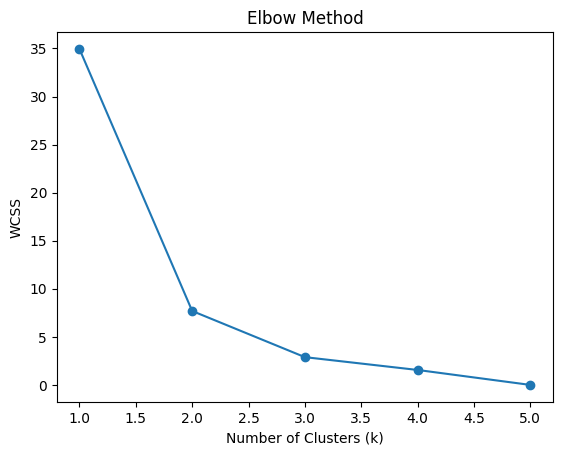

In [7]:
wcss = []
for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#Graph    
plt.plot(range(1, 6), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

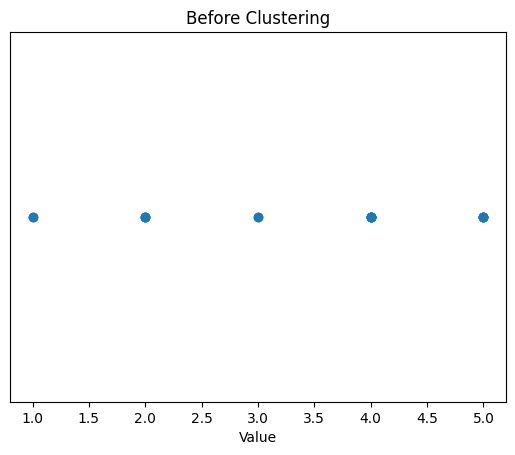

In [8]:
# before clustering
plt.figure()
plt.scatter(df["Value"], [0]*len(df))
plt.title("Before Clustering")
plt.xlabel("Value")
plt.yticks([])
plt.show()

In [9]:
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
df["Cluster"].head(10)

0    0
1    0
2    0
3    0
4    1
5    0
6    0
7    0
8    1
9    0
Name: Cluster, dtype: int32

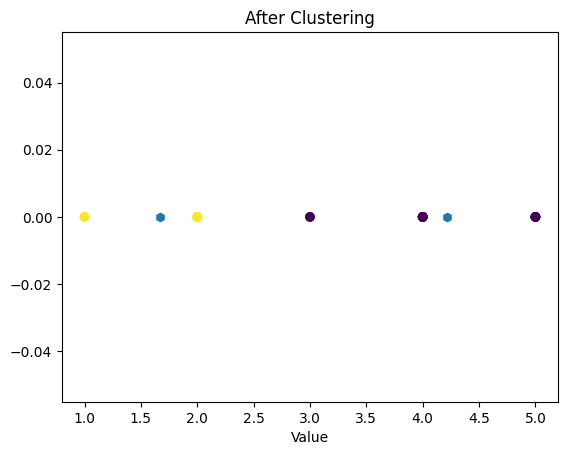

In [10]:
plt.figure()
plt.scatter(df["Value"], [0]*len(df), c=df["Cluster"])
plt.scatter(centroids[:, 0], [0]*len(centroids), marker='h')
plt.title("After Clustering")
plt.xlabel("Value")
plt.show()

In [11]:
print("\nClustered Data:")
print(df.head(10))


Clustered Data:
   Value  Cluster
0      3        0
1      4        0
2      5        0
3      4        0
4      1        1
5      3        0
6      4        0
7      4        0
8      1        1
9      4        0


In [ ]:
#DECISION TREE

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

np.random.seed(42)
num_students = 100
hours_studied = np.random.randint(1, 21, size=num_students)
attendance_percent = np.random.randint(40, 101, size=num_students)

# Target Variable: Did they pass? (1 for Yes, 0 for No)
passed_exam = []
for i in range(num_students):
    if hours_studied[i] > 8 and attendance_percent[i] > 70:
        passed_exam.append(np.random.choice([1, 0], p=[0.9, 0.1])) # 90% chance of passing
    else:
        passed_exam.append(np.random.choice([1, 0], p=[0.2, 0.8])) # 20% chance of passing
df = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Attendance': attendance_percent,
    'Passed': passed_exam
})
print(df.head(15))

    Hours_Studied  Attendance  Passed
0               7          74       0
1              20          83       1
2              15          79       1
3              11          61       1
4               8          66       0
5               7          74       0
6              19          40       0
7              11          74       1
8              11          76       1
9               4          86       0
10              8          53       0
11              3          42       0
12              2          40       0
13             12          44       0
14              6          65       0


In [18]:
X = df[['Hours_Studied', 'Attendance']] 
y = df['Passed']                       
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [19]:
y_pred = clf.predict(X_test)
print(y_pred)
print()
print(y_test)

[1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1]

83    1
53    1
70    1
45    1
44    1
39    0
22    0
80    0
10    0
0     0
18    0
30    0
73    1
33    0
90    0
4     0
76    1
77    1
12    0
31    1
Name: Passed, dtype: int64


In [20]:
print(f''' Accuracy: {accuracy_score(y_test, y_pred)}
 Precision: {precision_score(y_test, y_pred,average='weighted')}
 Recall: {recall_score(y_test, y_pred,average='weighted')}
 F1-Score: {f1_score(y_test, y_pred,average='weighted')}''')

 Accuracy: 0.85
 Precision: 0.8821428571428571
 Recall: 0.85
 F1-Score: 0.844


In [21]:
#CONFUSION MATRIX
print(confusion_matrix(y_test, y_pred))

[[11  0]
 [ 3  6]]


In [22]:
#CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       1.00      0.67      0.80         9

    accuracy                           0.85        20
   macro avg       0.89      0.83      0.84        20
weighted avg       0.88      0.85      0.84        20



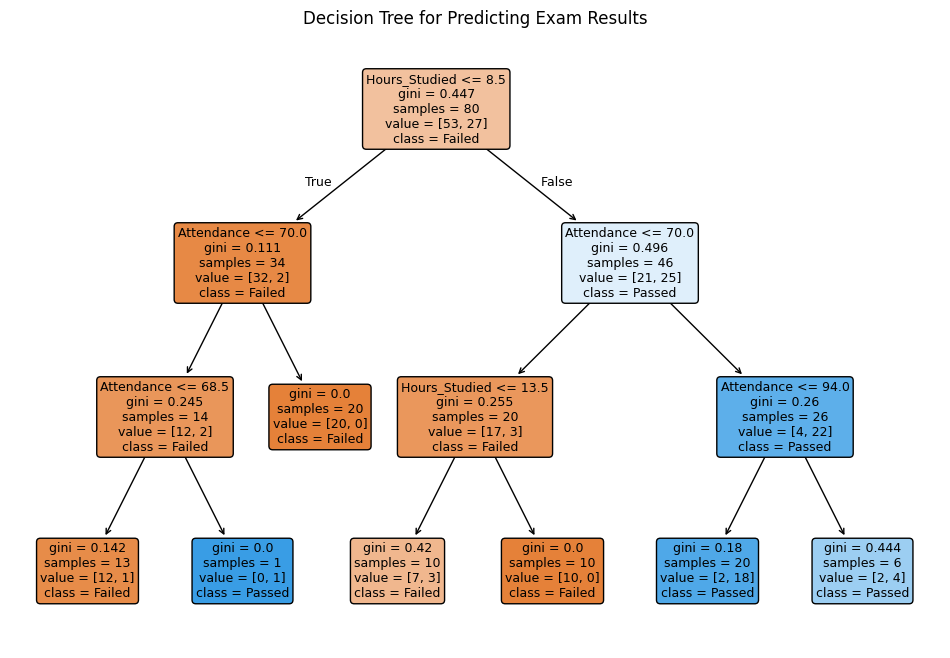

In [23]:
plt.figure(figsize=(12,8))
plot_tree(clf, 
          feature_names=['Hours_Studied', 'Attendance'], 
          class_names=['Failed', 'Passed'], 
          filled=True, 
          rounded=True)
plt.title("Decision Tree for Predicting Exam Results")
plt.show()